<h2 style = "color:green" >Advantages of this analysis</h2>

Identifies the real factors that drive engagement, especially media type, timing, and optimal post length.
Reveals the small group of users responsible for most discussions and distinguishes meaningful interactions from simple reactions.
Extracts key discussion topics automatically and detects repeated or templated service replies.
Shows when users are most active and how engagement quickly declines after posting.
Converts raw Telegram data into clean, ML-ready features for content strategy, moderation, and predictive modeling

In [47]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from langdetect import detect
import re
import emoji

In [48]:
# ================= PROJECT ROOT & DATA PATHS =================
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()  # fallback if running interactively

DEFAULT_DATA_DIR = Path(r"C:/Users/DELL/Documents/project_data/output")
DATA_DIR = Path(os.getenv("DATA_DIR", DEFAULT_DATA_DIR))

POSTS_PATH = DATA_DIR / "safaricom_posts.csv"
COMMENTS_PATH = DATA_DIR / "safaricom_comments22.csv"

# ================= FILE EXISTENCE CHECK =================
print("Using DATA_DIR:", DATA_DIR)
if not POSTS_PATH.exists():
    raise FileNotFoundError(f"Posts file not found: {POSTS_PATH}")
if not COMMENTS_PATH.exists():
    raise FileNotFoundError(f"Comments file not found: {COMMENTS_PATH}")

# ================= LOAD CSVs =================
posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)

#================== DATA INSPECTION =================
print("\n=== BEFORE PREPROCESSING ===")
print(f"Posts shape: {posts.shape}")
print(f"Comments shape: {comments.shape}")
print("\nMissing values per column (posts):")
print(posts.isna().sum())
print("\nMissing values per column (comments):")
print(comments.isna().sum())

print(f"\nDuplicate posts: {posts.duplicated(subset='msg_id').sum()}")
print(f"Duplicate comments: {comments.duplicated(subset='comment_id').sum()}")

Using DATA_DIR: C:\Users\DELL\Documents\project_data\output

=== BEFORE PREPROCESSING ===
Posts shape: (1948, 11)
Comments shape: (286376, 5)

Missing values per column (posts):
msg_id                0
date_utc              0
text                 39
views                 0
forwards              0
replies               0
has_media             0
media_type           28
sender_id             0
reply_to_msg_id    1943
num_comments          0
dtype: int64

Missing values per column (comments):
post_id           0
comment_id        0
date_utc          0
text           6840
sender_id     32160
dtype: int64

Duplicate posts: 0
Duplicate comments: 0


In [49]:
# ================= FILL MISSING VALUES =================
posts['views'] = posts['views'].fillna(0)
posts['forwards'] = posts['forwards'].fillna(0)
posts['replies'] = posts['replies'].fillna(0)
posts['media_type'] = posts['media_type'].fillna('Unknown')
posts['text'] = posts['text'].fillna('<media_only>')
posts['reply_to_msg_id'] = posts['reply_to_msg_id'].fillna('None')

comments['text'] = comments['text'].fillna('<deleted>')
comments['sender_id'] = comments['sender_id'].fillna('Unknown')


In [50]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Remove URLs (links)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 2. Remove mentions and hashtags (optional - keep if needed for analysis)
    text = re.sub(r'@\w+', '', text)  # remove @mentions
    # text = re.sub(r'#\w+', '', text)  # uncomment to remove hashtags
    
    # 3. Remove emojis OR convert them to text
    # Option A: Remove emojis
    text = emoji.replace_emoji(text, replace='')
    # Option B: Convert emojis to text (useful for sentiment)
    # text = emoji.demojize(text, delimiters=(":", ":"))
    
    # 4. Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\u1200-\u137F\s]', '', text)  # keeps Amharic and English
    
    # 5. Convert to lowercase (if English-heavy, but Amharic doesn't have case)
    text = text.lower()
    
    # 6. Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply cleaning
posts['cleaned_text'] = posts['text'].apply(clean_text)
comments['cleaned_text'] = comments['text'].apply(clean_text)

In [21]:
# =====================================================================
# 📱 ONE-CELL EMOJI DETECTION & ANALYSIS FOR TELECOM DATA
# =====================================================================
import emoji
from collections import Counter
import pandas as pd

# 1. Define Emoji Categories specific to Telecom / Social Media
POSITIVE_EMOJIS = set('😂😍❤️👍🔥🎉😘🥰💯👑🥳😊🤩💕👏😎🙌💖😋✨😇🫡')
NEGATIVE_EMOJIS = set('😡😤😢😭👎💔🤬😞😡🙅👎🏼😖😞😔😓😕😑😣😩😫🥺😢😭😤😡')
QUESTION_EMOJIS = set('❓❔🤔🫤')

def analyze_emoji(text):
    """Extracts emojis, counts them, and assigns a basic sentiment category."""
    text = str(text)
    found_emojis = [char for char in text if char in emoji.EMOJI_DATA]
    
    if not found_emojis:
        return pd.Series(["None", 0, "None"])
    
    emoji_string = " ".join(found_emojis)
    count = len(found_emojis)
    
    # Categorize based on presence of specific emojis
    if any(e in found_emojis for e in NEGATIVE_EMOJIS):
        category = "Negative/Complaint"
    elif any(e in found_emojis for e in QUESTION_EMOJIS):
        category = "Confusion/Question"
    elif any(e in found_emojis for e in POSITIVE_EMOJIS):
        category = "Positive/Hype"
    else:
        category = "Neutral/Other"
        
    return pd.Series([emoji_string, count, category])

print("⏳ Processing 286k rows for emojis... (May take 5-10 seconds)")

# 2. Apply to DataFrame and create new columns
comments[['emoji_text', 'emoji_count', 'emoji_sentiment']] = comments['text'].apply(analyze_emoji)

# 3. Isolate the "Lost" Data (Comments that became empty after text cleaning)
# We look at rows where cleaned_text is empty but original text had emojis
emoji_only_comments = comments[
    (comments['cleaned_text'].str.strip() == '') & 
    (comments['emoji_count'] > 0)
]

# 4. Isolate comments that MIXED text and emojis
mixed_emoji_comments = comments[
    (comments['cleaned_text'].str.strip() != '') & 
    (comments['emoji_count'] > 0)
]

# =====================================================================
# 📊 PRINTING THE ANALYSIS REPORT
# =====================================================================
print("\n" + "="*50)
print("📊 EMOJI ANALYSIS REPORT")
print("="*50)

print(f"\n1. OVERALL EMOJI USAGE:")
print(f"   - Total comments WITH emojis: {comments['emoji_count'].gt(0).sum():,} ({comments['emoji_count'].gt(0).mean()*100:.1f}%)")
print(f"   - Total comments WITHOUT emojis: {comments['emoji_count'].eq(0).sum():,}")
print(f"   - Total individual emojis extracted: {comments['emoji_count'].sum():,}")

print(f"\n2. THE 'LOST' BUCKET (Emoji-Only Comments):")
print(f"   - Recovered from 'unknown/other': {len(emoji_only_comments):,} comments")
if len(emoji_only_comments) > 0:
    print(f"   - Sentiment breakdown of Emoji-Only:")
    print(emoji_only_comments['emoji_sentiment'].value_counts().to_string(index=False).replace('\n', '\n     '))

print(f"\n3. SENTIMENT OF EMOJIS ACROSS ALL COMMENTS:")
print(comments[comments['emoji_count'] > 0]['emoji_sentiment'].value_counts().to_string())

print(f"\n4. TOP 15 MOST USED EMOJIS (Entire Dataset):")
all_emojis_flat = [e for row in comments['emoji_text'] if row != "None" for e in row.split()]
top_emojis = Counter(all_emojis_flat).most_common(15)
for em, cnt in top_emojis:
    print(f"   {em}  :  {cnt:,} times")

print(f"\n5. IMPACT ON MIXED COMMENTS (Text + Emoji):")
print(f"   - Out of {len(mixed_emoji_comments):,} comments with both text and emojis:")
print(mixed_emoji_comments['emoji_sentiment'].value_counts().to_string(index=False).replace('\n', '\n     '))

print("\n" + "="*50)
print("✅ New columns added to 'comments' df: ['emoji_text', 'emoji_count', 'emoji_sentiment']")
print("="*50)

⏳ Processing 286k rows for emojis... (May take 5-10 seconds)

📊 EMOJI ANALYSIS REPORT

1. OVERALL EMOJI USAGE:
   - Total comments WITH emojis: 56,561 (19.8%)
   - Total comments WITHOUT emojis: 229,815
   - Total individual emojis extracted: 652,203

2. THE 'LOST' BUCKET (Emoji-Only Comments):
   - Recovered from 'unknown/other': 3,915 comments
   - Sentiment breakdown of Emoji-Only:
emoji_sentiment
     1909
     1647
      327
       32

3. SENTIMENT OF EMOJIS ACROSS ALL COMMENTS:
emoji_sentiment
Positive/Hype         39397
Neutral/Other         13395
Confusion/Question     1977
Negative/Complaint     1792

4. TOP 15 MOST USED EMOJIS (Entire Dataset):
   🖕  :  338,755 times
   😁  :  20,695 times
   👌  :  18,736 times
   🏽  :  17,039 times
   🥰  :  16,126 times
   🙌  :  13,184 times
   🙏  :  11,917 times
   🤞  :  11,794 times
   ☘  :  11,379 times
   😉  :  10,274 times
   🤩  :  9,113 times
   👍  :  8,716 times
   🎉  :  8,118 times
   🎁  :  7,923 times
   😍  :  7,307 times

5. IMPACT 

In [52]:
# Displays the list of all columns
print(comments.columns)

# Displays names, non-null counts, and memory usage
print(comments.info())

Index(['post_id', 'comment_id', 'date_utc', 'text', 'sender_id',
       'cleaned_text'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286376 entries, 0 to 286375
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   post_id       286376 non-null  int64 
 1   comment_id    286376 non-null  int64 
 2   date_utc      286376 non-null  object
 3   text          286376 non-null  object
 4   sender_id     286376 non-null  object
 5   cleaned_text  286376 non-null  object
dtypes: int64(2), object(4)
memory usage: 13.1+ MB
None


In [53]:
#========================= feature engineering =========================
# For posts
posts['text_length'] = posts['cleaned_text'].str.len()
posts['word_count'] = posts['cleaned_text'].str.split().str.len()
posts['has_question'] = posts['cleaned_text'].str.contains('\?').astype(int)

# Feature engineering for comments
comments['text_length'] = comments['cleaned_text'].str.len()
comments['word_count'] = comments['cleaned_text'].str.split().str.len()

----------------------------------------------------------------------------------------------------------
<h5 style ="color:purple"> Distribution of Comments per Post (Histogram & Boxplot)</h5>

This figure shows how comments are distributed across posts. Most posts receive a small number of comments, while a few posts receive extremely high numbers. The boxplot confirms the presence of strong outliers (viral posts). This indicates that engagement is highly uneven and dominated by a small subset of posts.

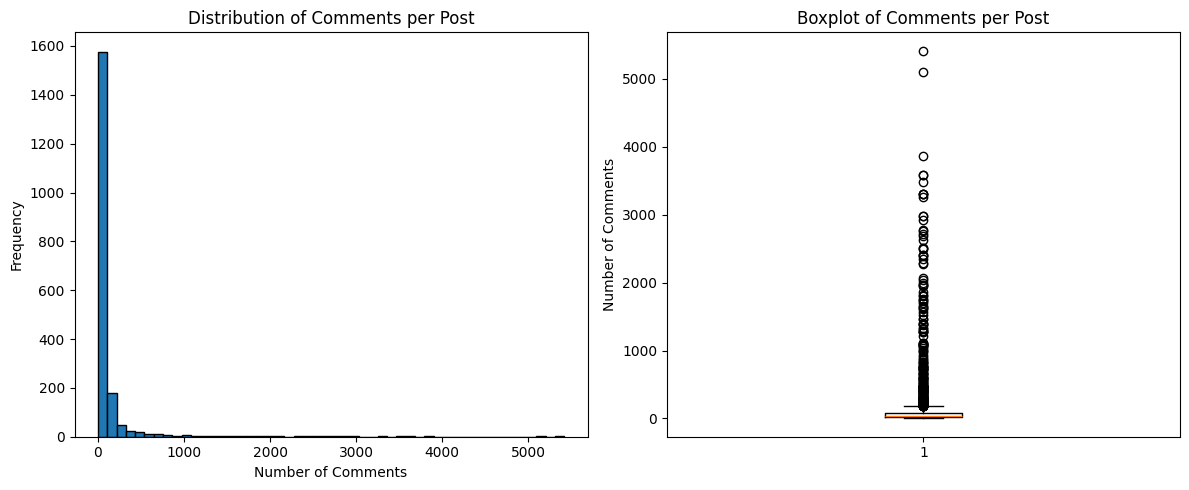

In [54]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(posts['num_comments'], bins=50, edgecolor='black')
plt.title('Distribution of Comments per Post')
plt.xlabel('Number of Comments')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(posts['num_comments'])
plt.title('Boxplot of Comments per Post')
plt.ylabel('Number of Comments')

plt.tight_layout()
plt.show()

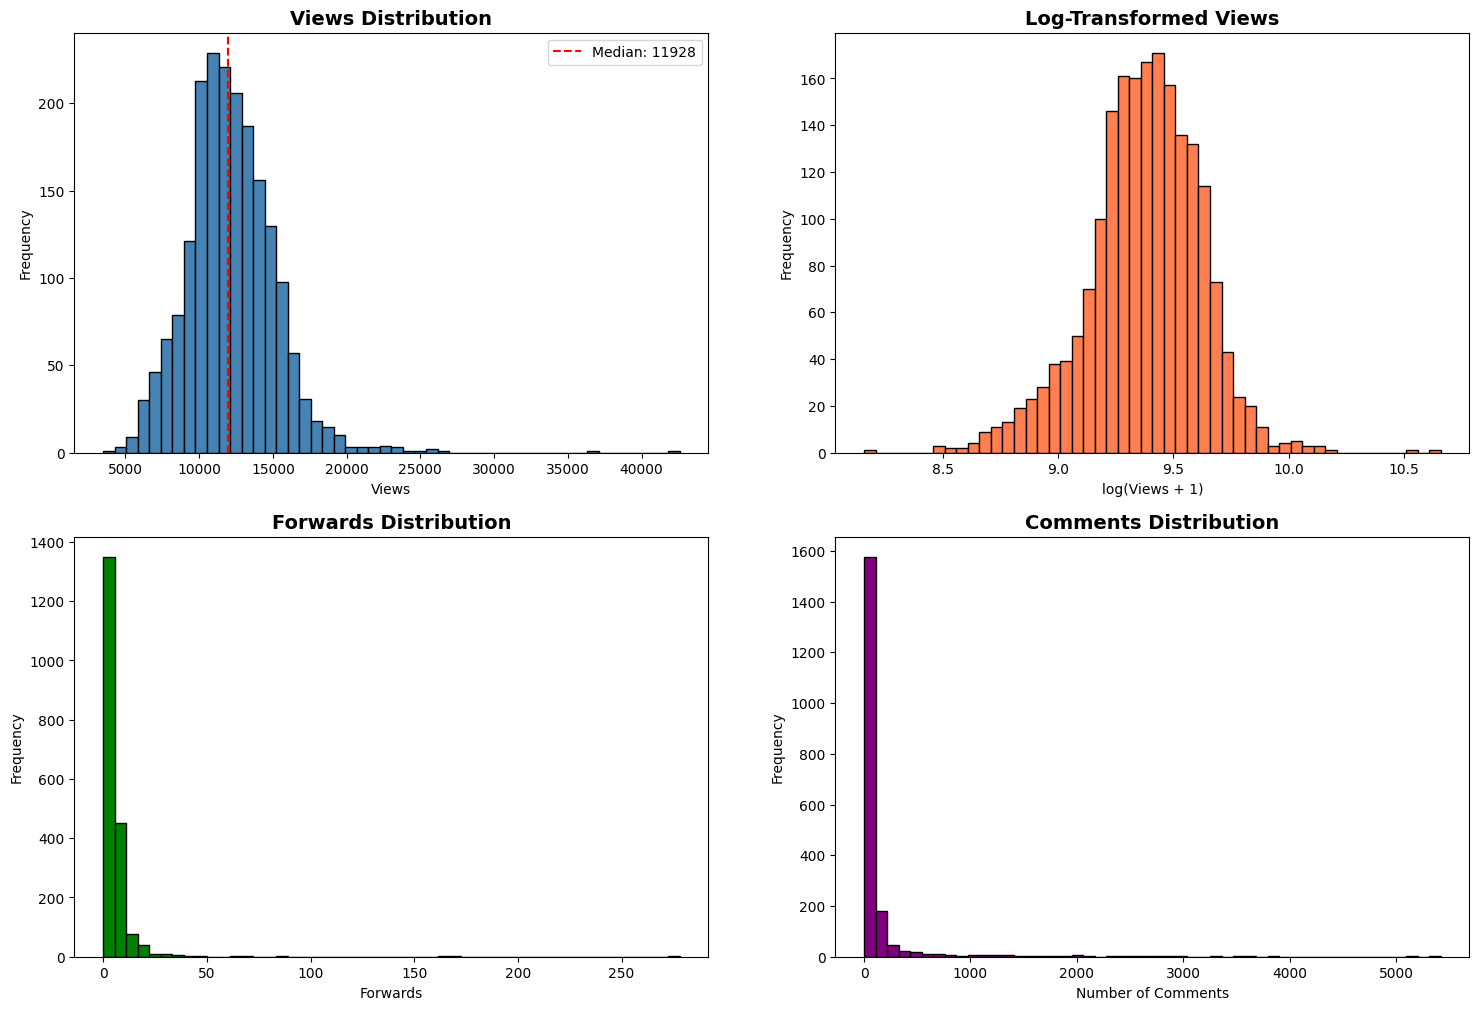

In [55]:
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Views distribution
axes[0, 0].hist(posts['views'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Views Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Views')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(posts['views'].median(), color='red', linestyle='--', label=f'Median: {posts["views"].median():.0f}')
axes[0, 0].legend()

# Log-transformed views
axes[0, 1].hist(np.log1p(posts['views']), bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Log-Transformed Views', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('log(Views + 1)')
axes[0, 1].set_ylabel('Frequency')

# Forwards distribution
axes[1, 0].hist(posts['forwards'], bins=50, color='green', edgecolor='black')
axes[1, 0].set_title('Forwards Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Forwards')
axes[1, 0].set_ylabel('Frequency')

# Comments distribution
axes[1, 1].hist(posts['num_comments'], bins=50, color='purple', edgecolor='black')
axes[1, 1].set_title('Comments Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Comments')
axes[1, 1].set_ylabel('Frequency')
plt.show()

----------------------------------------------------------------------------------------------------------
<h5 style = "color:purple"> Post Text Length Distribution & Text Length vs Comments</h5>

The histogram shows the range of post lengths, while the scatterplot compares post length with the number of comments. The absence of a clear pattern and the near-zero correlation indicate that longer posts do not necessarily generate more engagement. Content relevance matters more than text size.

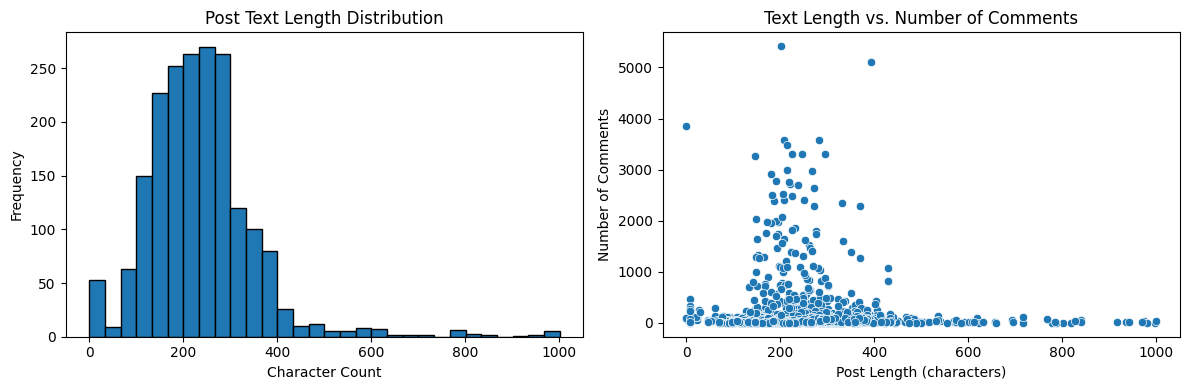

              text_length  num_comments
text_length      1.000000     -0.010929
num_comments    -0.010929      1.000000


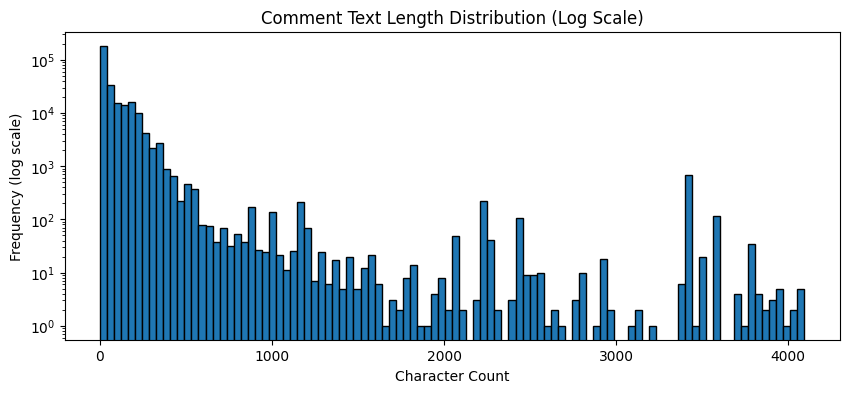

In [56]:
# Post text length distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(posts['text_length'], bins=30, edgecolor='black')
plt.title('Post Text Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.scatterplot(x=posts['text_length'], y=posts['num_comments'])
plt.title('Text Length vs. Number of Comments')
plt.xlabel('Post Length (characters)')
plt.ylabel('Number of Comments')

plt.tight_layout()
plt.show()

# Correlation
print(posts[['text_length', 'num_comments']].corr())

#======================= Comment level analysis ========================
plt.figure(figsize=(10, 4))
plt.hist(comments['text_length'], bins=100, edgecolor='black', log=True)
plt.title('Comment Text Length Distribution (Log Scale)')
plt.xlabel('Character Count')
plt.ylabel('Frequency (log scale)')
plt.show()

----------------------------------------------------------------------------------------------------------
<h4 style="color:purple"> Comments and post by Hour of Day and Day of Week</h4>

These bar charts show when users are most active. Clear peaks at certain hours and days reveal predictable engagement patterns. Posting during these peak periods can increase interaction.

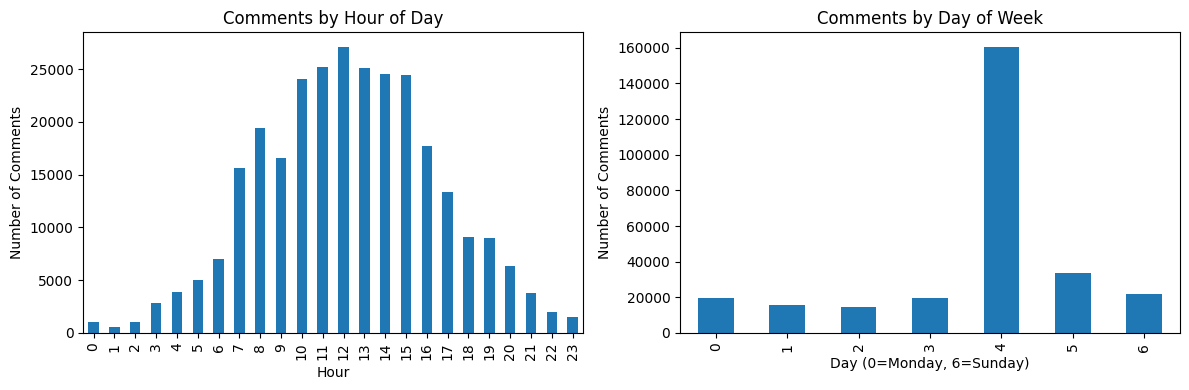

In [57]:
# Convert date_utc to datetime if not already
comments['date_utc'] = pd.to_datetime(comments['date_utc'])

# Comments by hour of day
comments['hour'] = comments['date_utc'].dt.hour
comments['day_of_week'] = comments['date_utc'].dt.dayofweek

# Plot comment activity by hour
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
comments['hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Comments by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Comments')

plt.subplot(1, 2, 2)
comments['day_of_week'].value_counts().sort_index().plot(kind='bar')
plt.title('Comments by Day of Week')
plt.xlabel('Day (0=Monday, 6=Sunday)')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

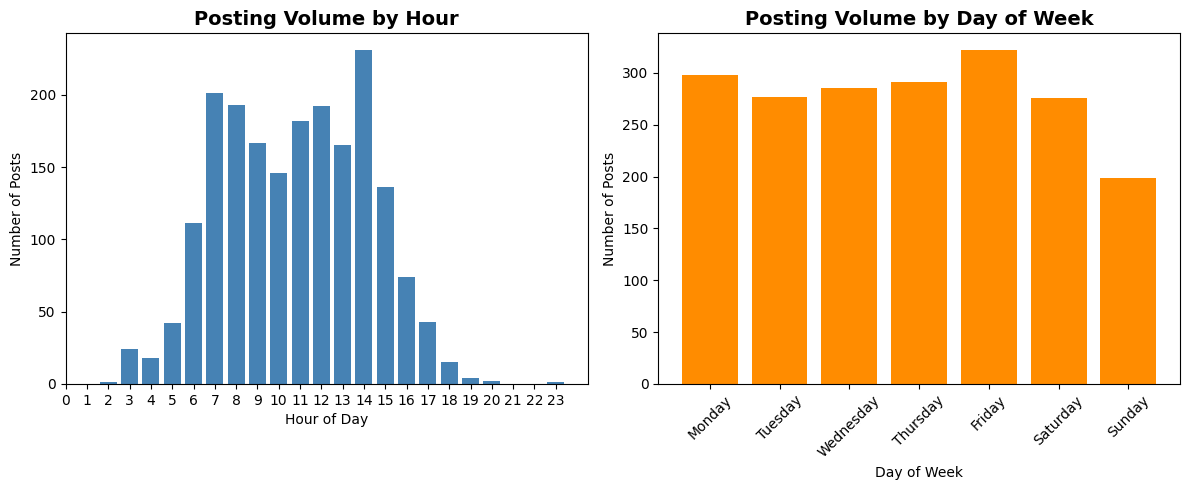

In [58]:
# Fix: ensure date_utc is datetime
posts['date_utc'] = pd.to_datetime(posts['date_utc'])

# Extract hour and day of week
posts['hour'] = posts['date_utc'].dt.hour
posts['day_of_week'] = posts['date_utc'].dt.day_name()

# Posting volume by hour
post_counts_by_hour = posts['hour'].value_counts().sort_index()

# Posting volume by day of week
post_counts_by_day = posts['day_of_week'].value_counts()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# By hour
axes[0].bar(post_counts_by_hour.index, post_counts_by_hour.values, color='steelblue')
axes[0].set_title('Posting Volume by Hour', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Posts')
axes[0].set_xticks(range(24))

# By day of week
post_counts_by_day = post_counts_by_day.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
axes[1].bar(post_counts_by_day.index, post_counts_by_day.values, color='darkorange')
axes[1].set_title('Posting Volume by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Posts')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------------------------
<h5 style="color:purple"> Cumulative Comment Growth Received Per Hour After Posting (Top Post)</h5>

This step plot shows how quickly comments accumulate after a post is published. Most comments occur within the first few hours, and activity slows down significantly afterward. Engagement is strongly front-loaded.  
And histogram shows how many comments arrive each hour after posting. The highest activity occurs early, followed by a rapid decline. Posts have a short active lifespan.


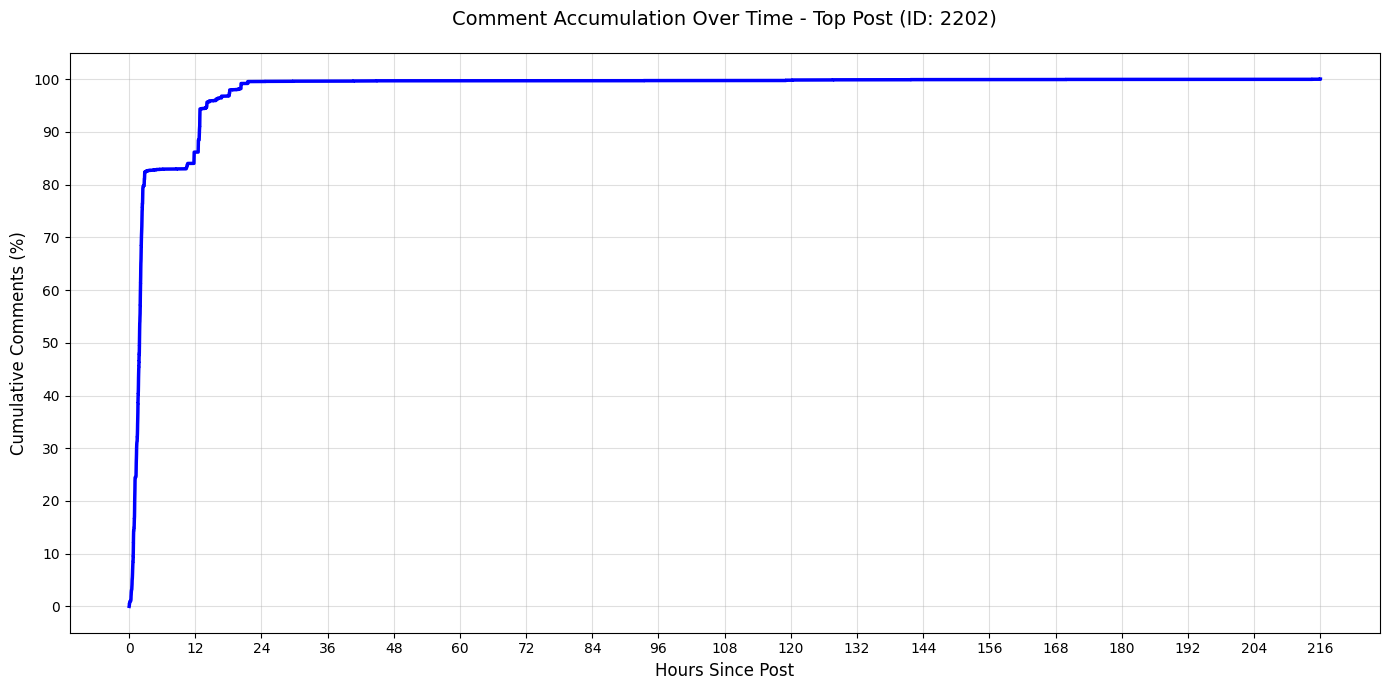

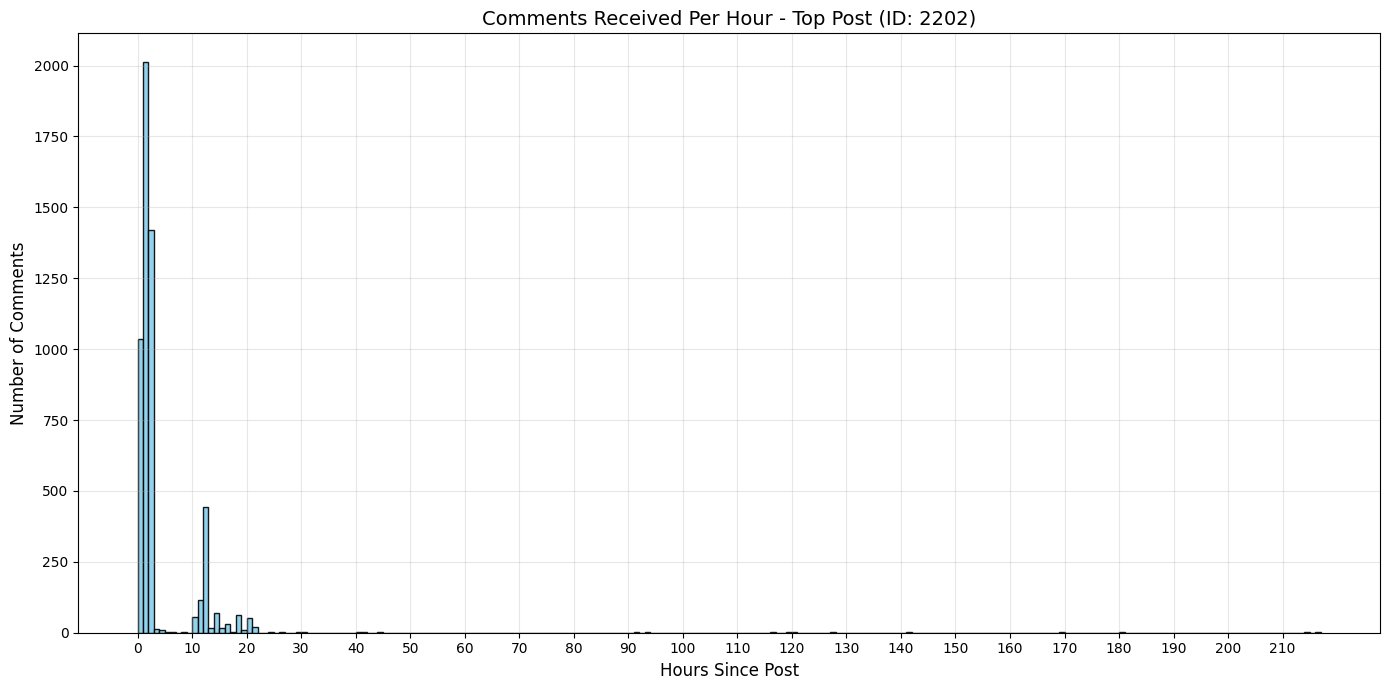

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Get top post
top_post_id = posts.nlargest(1, 'num_comments')['msg_id'].iloc[0]
top_post_comments = comments[comments['post_id'] == top_post_id].copy()

top_post_comments['date_utc'] = pd.to_datetime(top_post_comments['date_utc'])
post_time = pd.to_datetime(posts[posts['msg_id'] == top_post_id]['date_utc'].iloc[0])

top_post_comments['hours_since_post'] = (top_post_comments['date_utc'] - post_time).dt.total_seconds() / 3600

# ================= CLEAR VISUALIZATIONS =================

# 1. Cumulative Comments Over Time
plt.figure(figsize=(14, 7))
sorted_hours = np.sort(top_post_comments['hours_since_post'])
cumulative = np.arange(1, len(sorted_hours) + 1) / len(sorted_hours) * 100

plt.step(sorted_hours, cumulative, where='post', linewidth=2.5, color='blue')

plt.title(f'Comment Accumulation Over Time - Top Post (ID: {top_post_id})', fontsize=14, pad=20)
plt.xlabel('Hours Since Post', fontsize=12)
plt.ylabel('Cumulative Comments (%)', fontsize=12)

plt.grid(True, alpha=0.4)
plt.yticks(np.arange(0, 101, 10))
plt.xticks(range(0, int(sorted_hours.max()) + 1, 12), rotation=0)

plt.tight_layout()
plt.show()

# 2. Comments Per Hour - FIXED (Bigger gap, no overlap after 99)
plt.figure(figsize=(14, 7))
max_hour = int(top_post_comments['hours_since_post'].max()) + 2

plt.hist(top_post_comments['hours_since_post'], 
         bins=range(0, max_hour),
         edgecolor='black', color='skyblue', alpha=0.9)

plt.title(f'Comments Received Per Hour - Top Post (ID: {top_post_id})', fontsize=14)
plt.xlabel('Hours Since Post', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)

# Fixed: Much wider gap to prevent overlap
plt.xticks(range(0, max_hour, 10), rotation=0)   # Every 10 hours

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------------------------
<h5 style="color:purple"> Pareto Distribution of User Activity</h5>

This curve demonstrates that a small percentage of users contribute the majority of comments. Specifically, about 20% of users generate nearly 88% of all comments. Engagement is driven by a small core group of highly active users.

Top 20% of users contribute 87.6% of comments


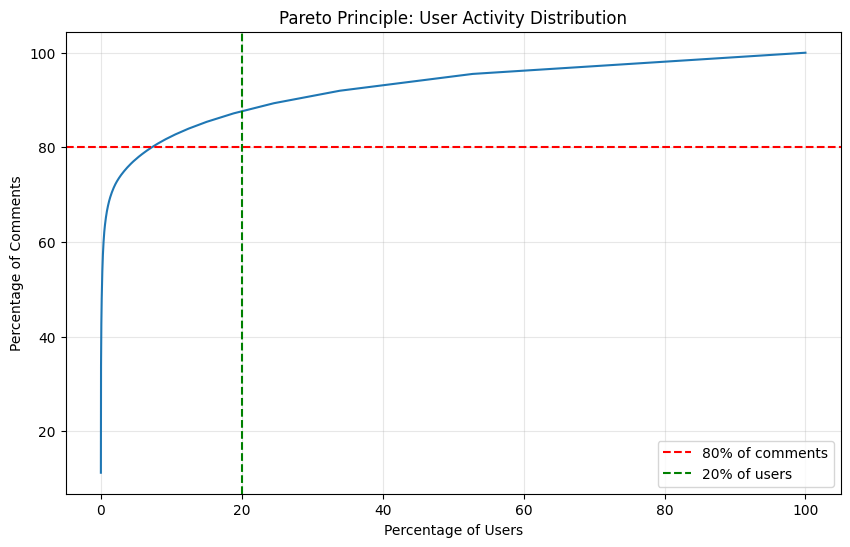

In [60]:
# Check if 20% of users make 80% of comments
user_comment_counts = comments['sender_id'].value_counts()
sorted_counts = user_comment_counts.sort_values(ascending=False)
cumulative_percentage = sorted_counts.cumsum() / sorted_counts.sum() * 100
users_percentage = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100

plt.figure(figsize=(10, 6))
plt.plot(users_percentage, cumulative_percentage)
plt.axhline(y=80, color='r', linestyle='--', label='80% of comments')
plt.axvline(x=20, color='g', linestyle='--', label='20% of users')
plt.title('Pareto Principle: User Activity Distribution')
plt.xlabel('Percentage of Users')
plt.ylabel('Percentage of Comments')
plt.legend()
plt.grid(True, alpha=0.3)

# Calculate actual percentage
top_20_percent_users = int(len(sorted_counts) * 0.2)
comments_from_top_20 = sorted_counts[:top_20_percent_users].sum()
print(f"Top 20% of users contribute {comments_from_top_20/sorted_counts.sum()*100:.1f}% of comments")

----------------------------------------------------------------------------------------------------------
<h5 style="color:purple"> User Comment Frequency per Post</h5>

This bar chart shows how many times the same user comments on a single post. Many users comment multiple times, and some extreme cases show very high repetition. This indicates ongoing discussions or repeated interactions within posts.


Users commenting multiple times on same post: 17160 instances
Average comments per user per post: 3.95
Max comments by same user on single post: 2348


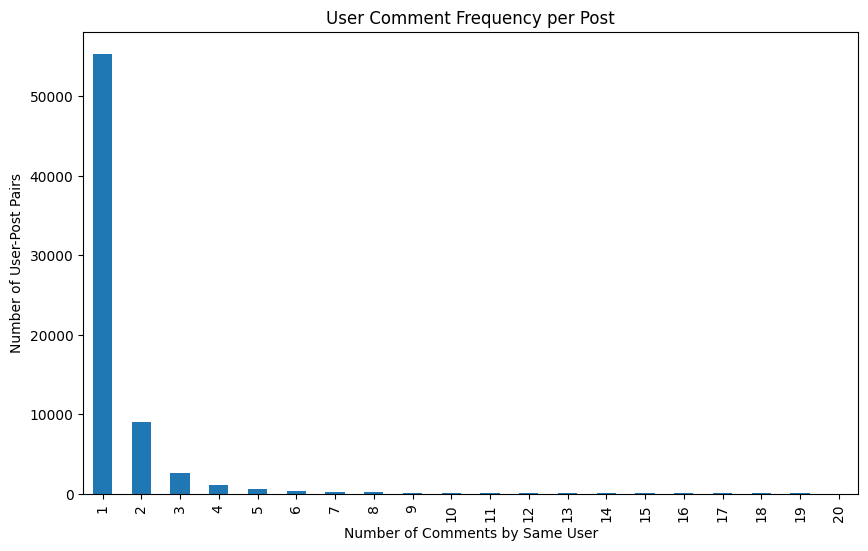

In [61]:
# Users who comment multiple times on same post
post_user_counts = comments.groupby(['post_id', 'sender_id']).size().reset_index(name='comments_per_user_per_post')
multi_commenters = post_user_counts[post_user_counts['comments_per_user_per_post'] > 1]

print(f"Users commenting multiple times on same post: {len(multi_commenters)} instances")
print(f"Average comments per user per post: {post_user_counts['comments_per_user_per_post'].mean():.2f}")
print(f"Max comments by same user on single post: {post_user_counts['comments_per_user_per_post'].max()}")

# Distribution
plt.figure(figsize=(10, 6))
post_user_counts['comments_per_user_per_post'].value_counts().sort_index().head(20).plot(kind='bar')
plt.title('User Comment Frequency per Post')
plt.xlabel('Number of Comments by Same User')
plt.ylabel('Number of User-Post Pairs')
plt.show()

=== TOP 20 COMMENTERS ===
          sender_id  total_comments  posts_commented  avg_comment_length  \
27164       Unknown           32160             1003          180.223601   
25550  7968479981.0           31555              874          155.275519   
17848  6612298661.0           12674               90           31.976566   
12485  5695848541.0            8030              156           41.125654   
12620  5726191544.0            4983              164           76.657837   
16434  6424639531.0            4527              130           27.472498   
22255  7249856496.0            3260               93           37.227914   
24581  7737717374.0            3156               70           94.005070   
25673  8001249912.0            2470              114          182.663968   
3302    609992025.0            2379              116           10.284153   
22292  7257252280.0            2359               94           24.744807   
3806    669490612.0            2351                4          

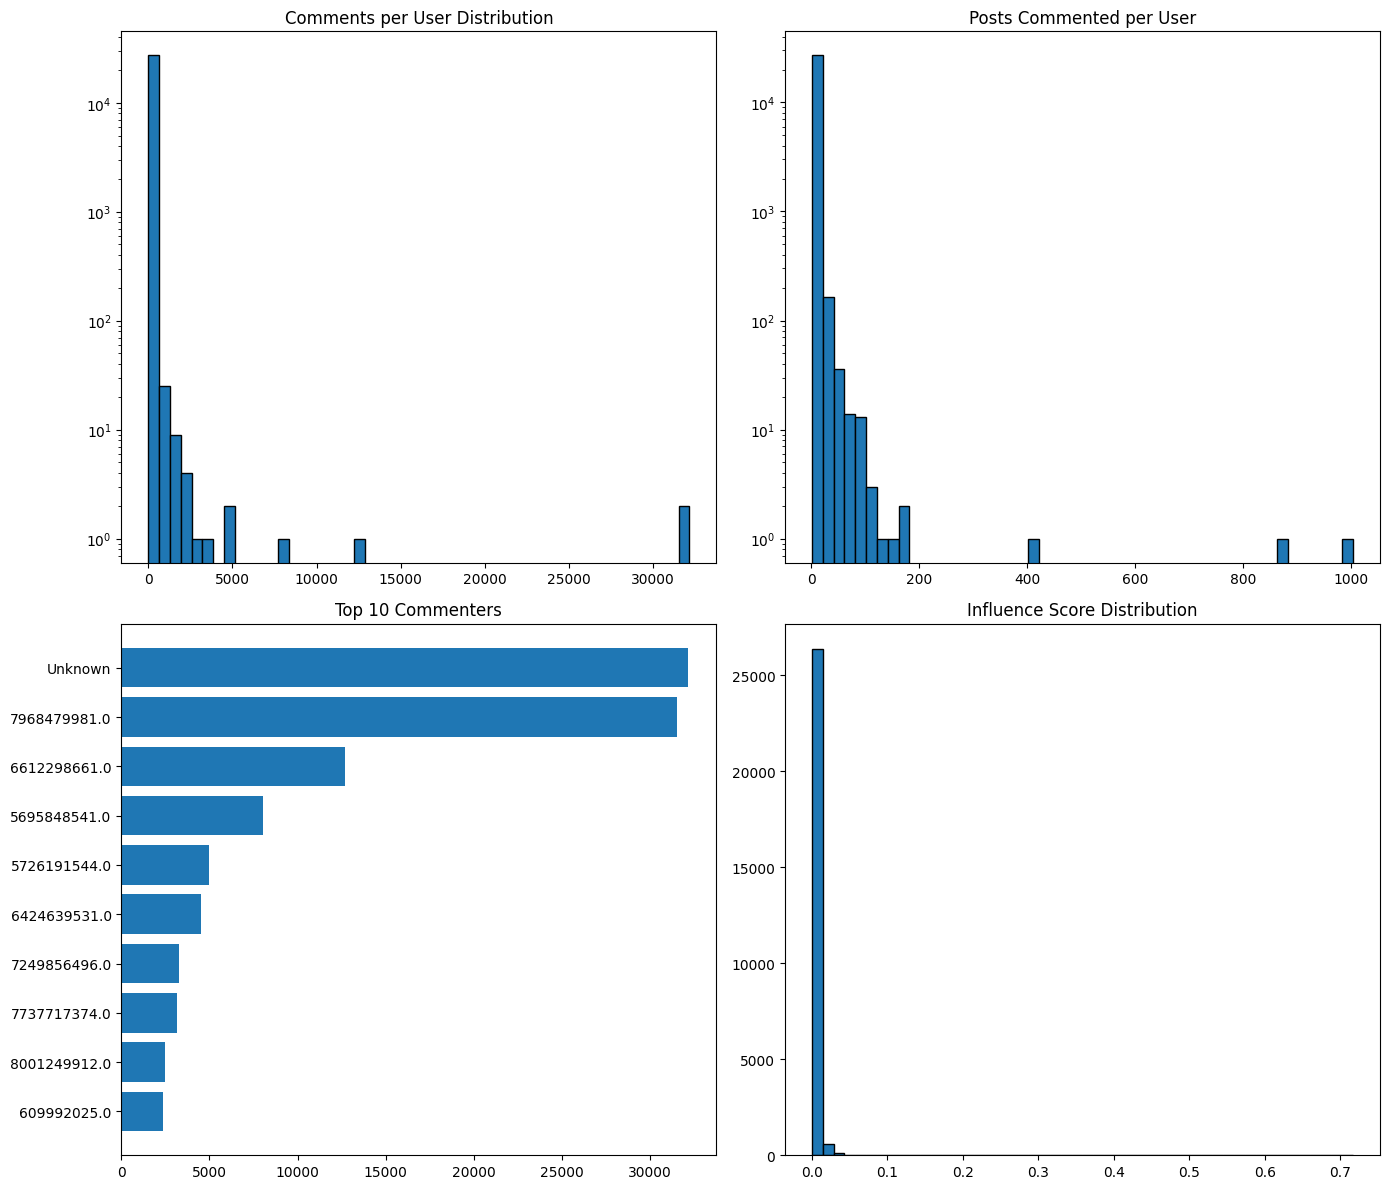

In [62]:
# ============================================
# 6.1 INFLUENTIAL USERS ANALYSIS (Corrected)
# ============================================

import matplotlib.pyplot as plt

# ----- User statistics from comments -----
user_stats = comments.groupby('sender_id').agg(
    total_comments=('comment_id', 'count'),
    posts_commented=('post_id', 'nunique'),
    avg_comment_length=('cleaned_text', lambda x: x.str.len().mean())
).reset_index()

# Avoid division issues
user_stats['posts_commented'] = user_stats['posts_commented'].replace(0, 1)

# Comment frequency
user_stats['comment_frequency'] = (
    user_stats['total_comments'] / user_stats['posts_commented']
)

# ----- Influence Score (normalized) -----
user_stats['influence_score'] = (
    0.4 * (user_stats['total_comments'] / user_stats['total_comments'].max()) +
    0.3 * (user_stats['posts_commented'] / user_stats['posts_commented'].max()) +
    0.3 * (user_stats['avg_comment_length'] / user_stats['avg_comment_length'].max())
)

# ----- Top commenters -----
print("=== TOP 20 COMMENTERS ===")
print(user_stats.sort_values('total_comments', ascending=False).head(20))

# ============================================
# Visualization
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Distribution: comments per user
axes[0, 0].hist(user_stats['total_comments'], bins=50, edgecolor='black')
axes[0, 0].set_title('Comments per User Distribution')
axes[0, 0].set_yscale('log')

# Distribution: posts commented per user
axes[0, 1].hist(user_stats['posts_commented'], bins=50, edgecolor='black')
axes[0, 1].set_title('Posts Commented per User')
axes[0, 1].set_yscale('log')

# Top 10 commenters
top10 = user_stats.nlargest(10, 'total_comments')
axes[1, 0].barh(top10['sender_id'].astype(str), top10['total_comments'])
axes[1, 0].set_title('Top 10 Commenters')
axes[1, 0].invert_yaxis()

# Influence score distribution
axes[1, 1].hist(user_stats['influence_score'], bins=50, edgecolor='black')
axes[1, 1].set_title('Influence Score Distribution')

plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------------------------
<h5 style="color:purple"> Topic Modeling Results (LDA Topics)</h5>

These topics represent the main themes discussed in posts. The dominant themes include network services, promotions, M-PESA usage, and brand campaigns. This confirms that discussions are centered around service features and promotional content.

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation

# Create TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=1000)
post_vectors = vectorizer.fit_transform(posts['cleaned_text'])
comment_vectors = vectorizer.transform(comments['cleaned_text'])

# Calculate similarity between each comment and its parent post
# (you'd need to match comment to post_id)

# Topic modeling on posts
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
post_tfidf = tfidf.fit_transform(posts['cleaned_text'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(post_tfidf)

# Display topics
def display_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

display_topics(lda, tfidf.get_feature_names_out(), 10)

Topic 0:
እና ኢትዮጵያ ጋር ነው ደቂቃ አገልግሎት ሙዚቃ የዲጂታል ላይ ቅመም
Topic 1:
safaricomethiopia ወደፊት እንኳን እና ኔትዎርክ furtheraheadtogether በአብሮነት አሁንም wedefit መልካም
Topic 2:
ከሳፋሪኮም ወደ በሽ ብለን ወይም wedefit በመላክ እናዉርድ ቁጥራችን ጋር
Topic 3:
ልዩ ጥቅል mediaonly ዳታ እንግዛ safaricomethiopia ያልተገደበ ጊባ የዳታ ሳፋሪኮም
Topic 4:
በmpesa mpesa እናውርድ መተግበሪያን ወይም የmpesa የበሽ የቴሌግራም ላይ እዚህ


----------------------------------------------------------------------------------------------------------
<h3 style="color:green"> 1. Text Content Analysis</h3>
<h5 style="color:purple">A. Word Clouds and Most Frequent Words</h5>

The word clouds visualize the most common words in posts and comments. Frequently appearing terms relate to network services, minutes, bundles, and brand names, highlighting the main focus of user discussions.


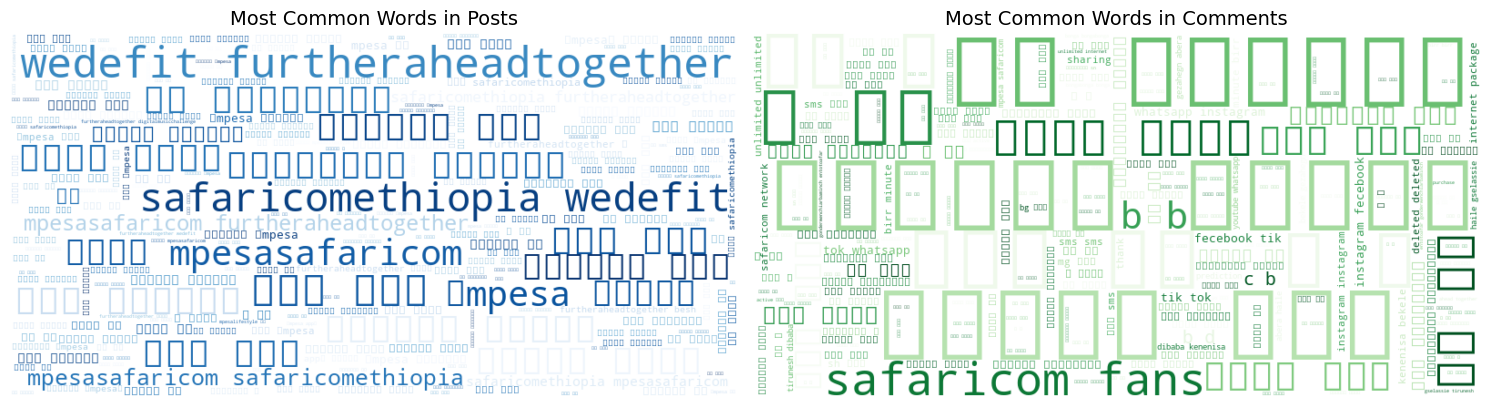

Top 20 words in comments:
  ደቂቃ: 135023
  ኔትወርክ: 106328
  በተመሳሳይ: 104199
  for: 46117
  safaricom: 44179
  ሰላም፣: 32884
  መልካም: 32784
  ክሬዲት: 31186
  fans: 30018
  ላይክ: 24488
  the: 23075
  ዕድል: 22032
  ምንም: 21053
  ጥቅል: 18142
  mpesa: 16557
  your: 15517
  instagram: 15073
  you: 14148
  ካርድ: 13982
  birr: 13304


In [65]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import re

# Combine all post texts
all_post_text = ' '.join(posts['cleaned_text'].dropna())
all_comment_text = ' '.join(comments['cleaned_text'].dropna())

# Create word clouds
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
wordcloud_posts = WordCloud(width=800, height=400, background_color='white', 
                           colormap='Blues', font_path=None).generate(all_post_text)
plt.imshow(wordcloud_posts, interpolation='bilinear')
plt.title('Most Common Words in Posts', fontsize=14)
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_comments = WordCloud(width=800, height=400, background_color='white',
                               colormap='Greens', font_path=None).generate(all_comment_text)
plt.imshow(wordcloud_comments, interpolation='bilinear')
plt.title('Most Common Words in Comments', fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

# Top 20 words in comments (excluding stop words)
stop_words = {'ለ', 'በ', 'እና', 'የ', 'እንደ', 'ላይ', 'ታይ', 'ነው', 'ማድረግ', 'ቁም'}
comment_words = all_comment_text.split()
comment_word_freq = Counter([w for w in comment_words if w not in stop_words and len(w) > 2])
print("Top 20 words in comments:")
for word, count in comment_word_freq.most_common(20):
    print(f"  {word}: {count}")

----------------------------------------------------------------------------------------------------------
<h5 style="color:purple">B. N-gram/Common Bigrams and Trigrams Analysis (Common Phrases)</h5>

This analysis shows frequently repeated phrases. Many phrases are promotional or templated, indicating repeated messaging patterns across posts and comments.


In [66]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigrams in comments
vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=20)
comment_bigrams = vectorizer.fit_transform(comments['cleaned_text'].dropna())
bigram_counts = comment_bigrams.toarray().sum(axis=0)
bigram_names = vectorizer.get_feature_names_out()

print("Top 10 bigrams/trigrams in comments:")
for name, count in sorted(zip(bigram_names, bigram_counts), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {name}: {count}")

Top 10 bigrams/trigrams in comments:
  በተመሳሳይ ኔትወርክ: 103906
  ጥሪ በተመሳሳይ: 100186
  ደቂቃ ጥሪ: 100136
  ደቂቃ ጥሪ በተመሳሳይ: 100129
  ጥሪ በተመሳሳይ ኔትወርክ: 99990
  ኔትወርክ ደቂቃ: 98731
  ኔትወርክ ደቂቃ ጥሪ: 97344
  በተመሳሳይ ኔትወርክ ደቂቃ: 97308
  ጊዜ ጊዜ: 85050
  ጊዜ ጊዜ ጊዜ: 84666


----------------------------------------------------------------------------------------------------------
<h3 style="color:green">2. Engagement Pattern Analysis</h3>
<h5 style="color:purple">A. Engagement by Post Word Count Category</h5>

This plot compares comment counts across different post length categories. Medium-length posts generate the highest engagement, while very long posts receive fewer comments. There is an optimal content length for interaction.


Engagement by word count category:
                  mean  median  count
word_cat                             
Very Short   82.987179    52.0     78
Short        93.828423    31.0    577
Medium      200.170264    41.0    834
Long        128.222488    58.0    418
Very Long    24.676471    14.0     34


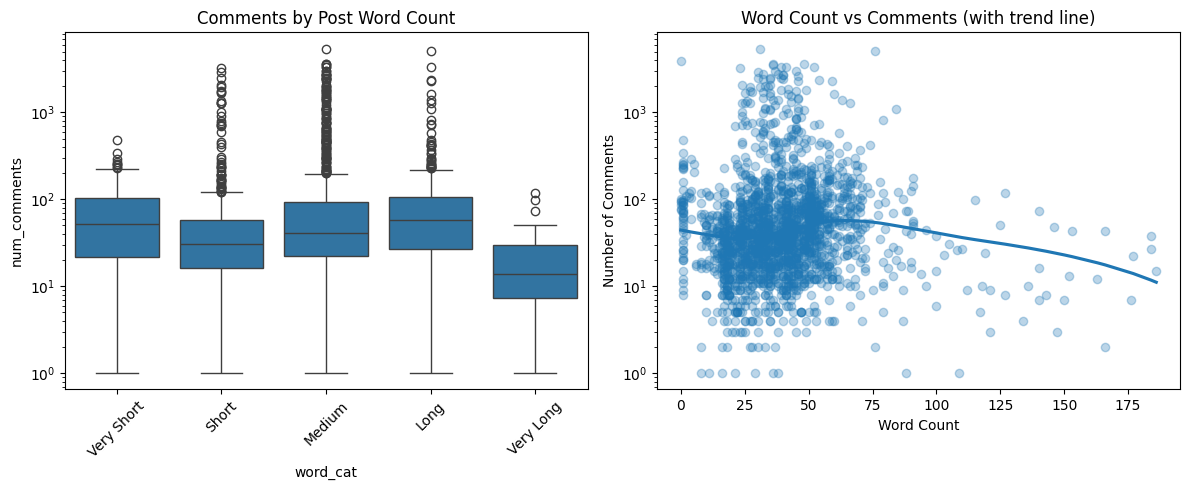

Spearman correlation: 0.138 (p=0.0000)


In [67]:
# Create word count categories
posts['word_cat'] = pd.cut(posts['word_count'], 
                           bins=[0, 10, 30, 50, 100, 500], 
                           labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])

# Engagement by word count
wc_engagement = posts.groupby('word_cat', observed=True)['num_comments'].agg(['mean', 'median', 'count'])
print("Engagement by word count category:")
print(wc_engagement)

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='word_cat', y='num_comments', data=posts, order=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])
plt.title('Comments by Post Word Count')
plt.yscale('log')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
# Scatter plot with trend line
sns.regplot(x='word_count', y='num_comments', data=posts, scatter_kws={'alpha':0.3}, lowess=True)
plt.title('Word Count vs Comments (with trend line)')
plt.xlabel('Word Count')
plt.ylabel('Number of Comments')
plt.yscale('log')

plt.tight_layout()
plt.show()

# Correlation (Spearman for non-linear)
from scipy.stats import spearmanr
corr, p_val = spearmanr(posts['word_count'], posts['num_comments'])
print(f"Spearman correlation: {corr:.3f} (p={p_val:.4f})")

----------------------------------------------
<h5 style="color:purple">B. Engagement by Media Type</h5>

This figure compares engagement across media formats. Photos, documents, and polls generate significantly more comments than web links. Media type strongly influences user interaction.

Media type distribution:
media_type
MessageMediaPhoto       1698
MessageMediaDocument     196
Unknown                   28
MessageMediaPoll          22
MessageMediaWebPage        4
Name: count, dtype: int64

Engagement by media type:
                        mean  median  count
media_type                                 
MessageMediaDocument  177.08    27.0    196
MessageMediaPhoto     142.56    41.0   1698
MessageMediaPoll      154.27    96.0     22
MessageMediaWebPage    15.25    15.5      4
Unknown               219.79    77.0     28


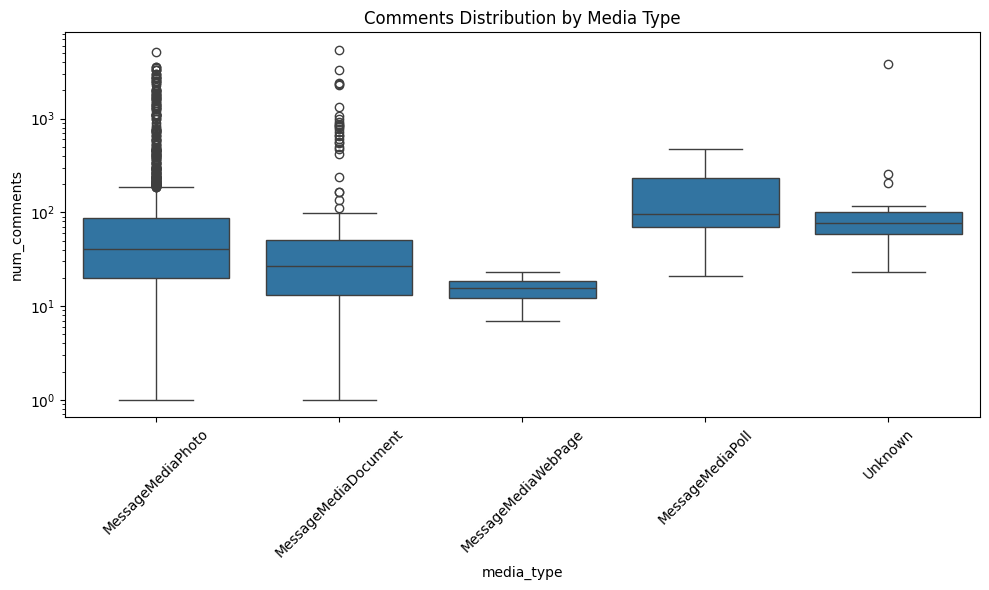

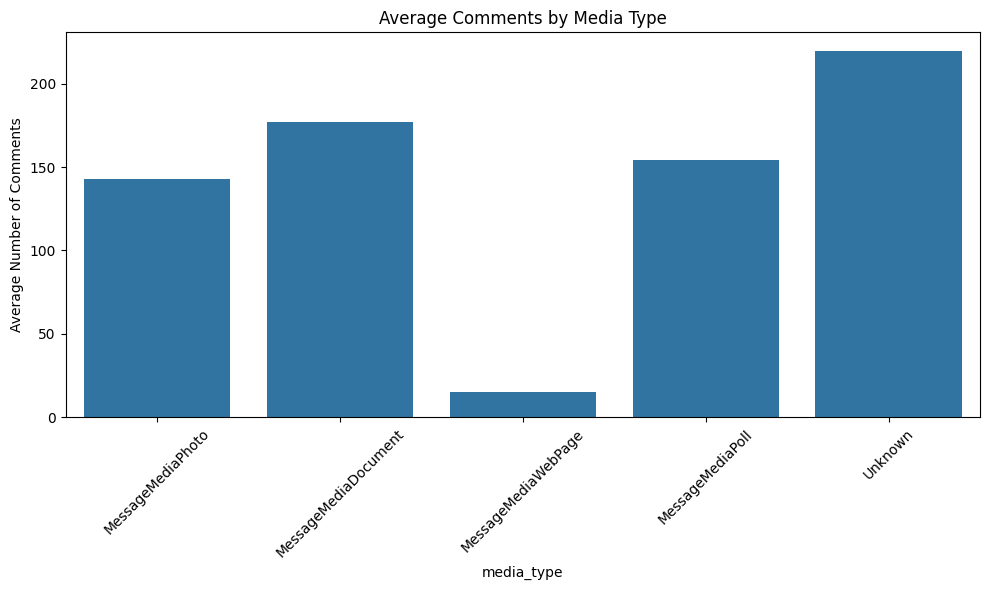


Kruskal-Wallis test p-value: 0.0000
Significant difference in engagement by media type: Yes

✅ Media type analysis completed.


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check media_type distribution
print("Media type distribution:")
print(posts['media_type'].value_counts())

# Engagement by media type
media_engagement = posts.groupby('media_type')['num_comments'].agg(['mean', 'median', 'count'])
print("\nEngagement by media type:")
print(media_engagement.round(2))

# ================= VISUALIZATIONS (Fixed) =================

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='media_type', y='num_comments', data=posts)
plt.title('Comments Distribution by Media Type')
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Barplot - Fixed (ci → errorbar)
plt.figure(figsize=(10, 6))
sns.barplot(x='media_type', y='num_comments', data=posts, errorbar=None)
plt.title('Average Comments by Media Type')
plt.xticks(rotation=45)
plt.ylabel('Average Number of Comments')
plt.tight_layout()
plt.show()

# Statistical test
media_types = posts['media_type'].dropna().unique()
if len(media_types) >= 2:
    from scipy.stats import kruskal
    groups = [posts[posts['media_type'] == mt]['num_comments'] for mt in media_types]
    h_stat, p_value = kruskal(*groups)
    print(f"\nKruskal-Wallis test p-value: {p_value:.4f}")
    print(f"Significant difference in engagement by media type: {'Yes' if p_value < 0.05 else 'No'}")

print("\n✅ Media type analysis completed.")

----------------------------------------------------------------------------------------------------------
<h3 style="color:green;">3️⃣ Sentiment & Quality Analysis</h3>
<h5 style="color:purple;">Long Comment Ratio as Engagement Quality Indicator</h5>

This analysis identifies posts that generate a high proportion of long comments. Such posts likely trigger deeper and more meaningful discussions rather than simple reactions.


In [69]:
# Long comments might indicate high engagement
long_comments = comments[comments['text_length'] > 100]
print(f"Long comments (>100 chars): {len(long_comments)} ({len(long_comments)/len(comments)*100:.2f}%)")

# Posts that generate long comments
post_long_comments = long_comments.groupby('post_id').size().reset_index(name='long_comments')
post_long_comments = post_long_comments.merge(posts[['msg_id', 'num_comments']], left_on='post_id', right_on='msg_id')
post_long_comments['long_comment_ratio'] = post_long_comments['long_comments'] / post_long_comments['num_comments']

top_quality_posts = post_long_comments.nlargest(10, 'long_comment_ratio')
print("\nPosts with highest proportion of long comments (potential quality engagement):")
print(top_quality_posts[['post_id', 'long_comment_ratio', 'num_comments']])

Long comments (>100 chars): 61425 (21.45%)

Posts with highest proportion of long comments (potential quality engagement):
      post_id  long_comment_ratio  num_comments
948      2740            1.000000             1
1252     3338            0.846154           559
414      1774            0.837349           166
803      2403            0.764192           229
615      2069            0.666667             3
717      2229            0.666667             9
900      2542            0.666667             3
1307     3432            0.666667             6
568      2006            0.631579            19
66       1268            0.600000             5


In [70]:
# Detect repeated comment patterns (customer service responses)

from difflib import SequenceMatcher

def find_similar_comments(comments_df, threshold=0.9):
    comments_sample = comments_df['cleaned_text'].head(1000)
    similar_pairs = []
    
    for i in range(len(comments_sample)):
        for j in range(i+1, min(i+100, len(comments_sample))):
            similarity = SequenceMatcher(None, comments_sample.iloc[i], comments_sample.iloc[j]).ratio()
            if similarity > threshold:
                similar_pairs.append((i, j, similarity))
    
    return similar_pairs

similar_comments = find_similar_comments(comments)
print(f"Found {len(similar_comments)} highly similar comment pairs")
print("This suggests template/canned responses, likely customer service")

Found 3088 highly similar comment pairs
This suggests template/canned responses, likely customer service


----------------------------------------------------------------------------------------------------------
<h5 style="color:purple"> Correlation Matrix of Post Features and Engagement</h5>

This heatmap shows relationships between post features and comment counts. Engagement is weakly related to text size but more influenced by media presence and visibility metrics like views and forwards.

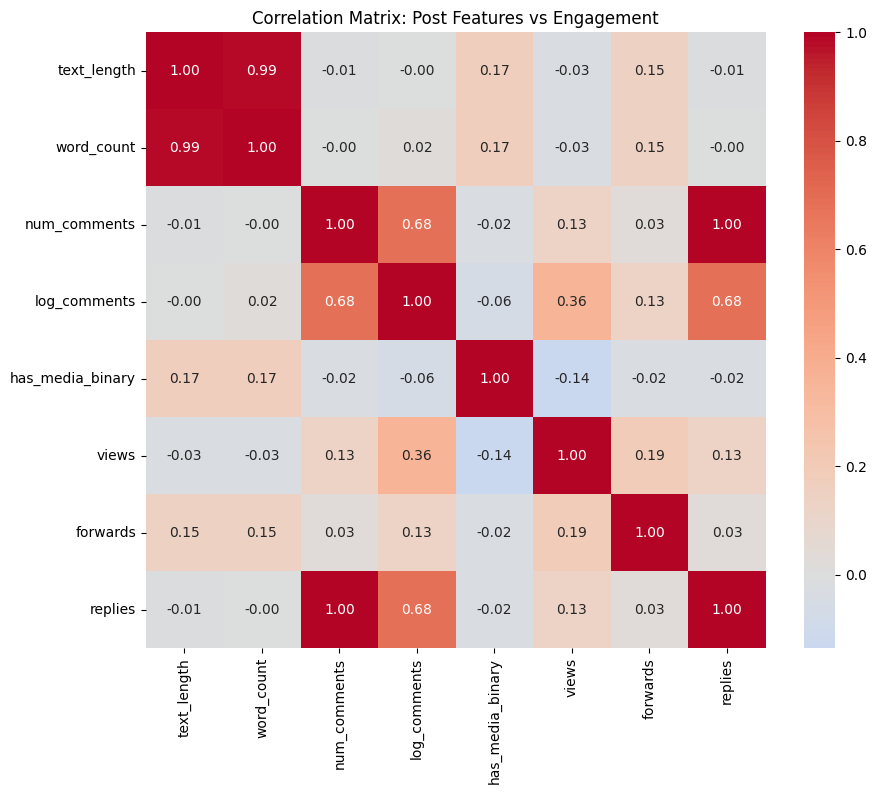


🔍 Key Correlations with num_comments:
  text_length: -0.011
  word_count: -0.002
  log_comments: 0.684
  has_media_binary: -0.020
  views: 0.134
  forwards: 0.025
  replies: 1.000


In [71]:
# Create features for correlation matrix
posts_eda = posts.copy()
posts_eda['log_comments'] = np.log1p(posts_eda['num_comments'])  # Log transform
posts_eda['has_media_binary'] = posts_eda['has_media'].astype(int)

# Select numeric columns
corr_cols = ['text_length', 'word_count', 'num_comments', 'log_comments', 
              'has_media_binary', 'views', 'forwards', 'replies']

corr_matrix = posts_eda[corr_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Post Features vs Engagement')
plt.show()

# Key insights
print("\n🔍 Key Correlations with num_comments:")
for col in corr_cols:
    if col != 'num_comments':
        corr = corr_matrix.loc[col, 'num_comments']
        print(f"  {col}: {corr:.3f}")

----------------------------------------------------------------------------------------------------------
<h4 style = "color:Indigo"> Viral Post Detection (Outlier Analysis)</h4>

Posts are labeled as viral if their comment count exceeds mean + 3×standard deviation, isolating extreme engagement outliers.
The top viral posts are then inspected to understand their text length and content patterns.
Textual cues such as exclamation marks, emojis, and reward-related words are examined.
This reveals common characteristics shared by unusually high-performing posts.
The goal is to understand what makes certain posts generate exceptionally high interaction.

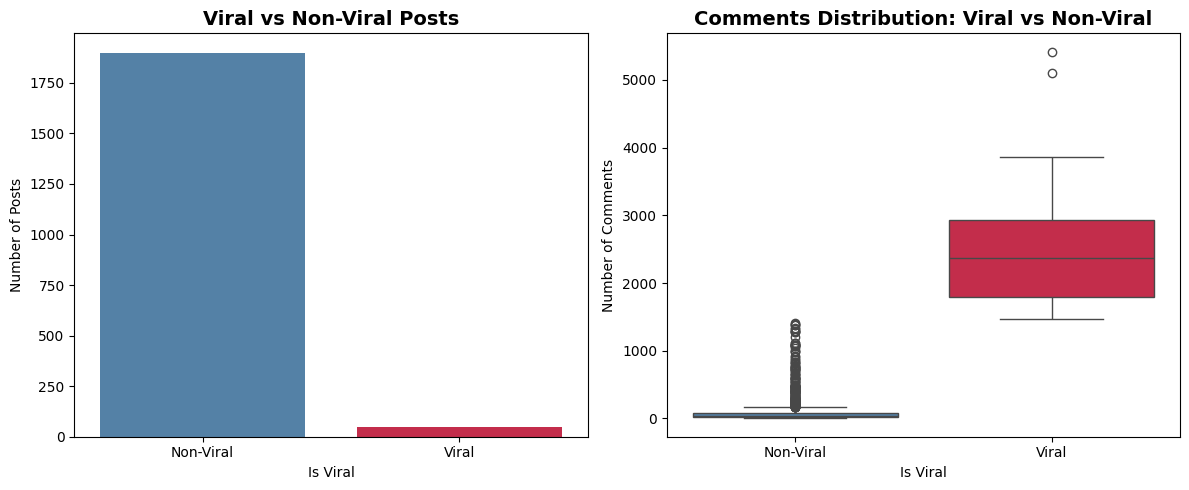

Viral Threshold: 1435 comments
Viral Posts: 48

Top 3 Viral Posts:

Post 1389: 5104 comments
Text: ፏ በአርብ በቅመም ሽልማት በሽ በሽ ወደ ቅመም የሚወስደው ትክክለኛ መንገድ የቱ ነው ትክክለኛውን መርጦ ለመለሰ ነገር ግን ምንም ላይክ ለሌለው ሰው ቅመም እን...
Length: 394 chars | Has question: 0

Post 1867: 1523 comments
Text: ፏ በአርብ የጀግኖቻችንን ድል ኦሎምፒኩ ከተካሄደበት ቦታ ጋር እናዛምድ ሁሉንም በትክክል ያገኙና ምንም ላይክ ለሌላቸው ሰዎች መርጠን ካርድ እንሸልማለን። የቴሌ...
Length: 262 chars | Has question: 0

Post 1886: 2976 comments
Text: ፏ በአርብ ኢትዮጵያን የድርብ ወርቅ ባለቤት ያደረጓት አትሌቶች እነማን ነበሩ ኮመንት ላይ ሁሉንም በመዘርዘር ምንም ላይክ ያላገኙ ሰዎችን መርጠን ካርድ እንሸል...
Length: 269 chars | Has question: 0


In [72]:
# Viral vs Non-Viral Posts Visualization - Fixed Warnings

import matplotlib.pyplot as plt
import seaborn as sns

# Identify viral posts
mean_comments = posts['num_comments'].mean()
std_comments = posts['num_comments'].std()
viral_threshold = mean_comments + 3 * std_comments

posts['is_viral'] = posts['num_comments'] > viral_threshold

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar: Viral vs Non-Viral Count
sns.countplot(data=posts, x='is_viral', hue='is_viral', palette=['steelblue', 'crimson'], 
              legend=False, ax=axes[0])
axes[0].set_title('Viral vs Non-Viral Posts', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Is Viral')
axes[0].set_ylabel('Number of Posts')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Viral', 'Viral'])

# Boxplot: Comments Distribution
sns.boxplot(data=posts, x='is_viral', y='num_comments', hue='is_viral', palette=['steelblue', 'crimson'], 
            legend=False, ax=axes[1])
axes[1].set_title('Comments Distribution: Viral vs Non-Viral', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Is Viral')
axes[1].set_ylabel('Number of Comments')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Viral', 'Viral'])

plt.tight_layout()
plt.show()

print(f"Viral Threshold: {viral_threshold:.0f} comments")
print(f"Viral Posts: {posts['is_viral'].sum()}")
print("\nTop 3 Viral Posts:")
for idx, row in posts[posts['is_viral']].head(3).iterrows():
    print(f"\nPost {row['msg_id']}: {row['num_comments']} comments")
    print(f"Text: {row['cleaned_text'][:100]}...")
    print(f"Length: {row['text_length']} chars | Has question: {row['has_question']}")

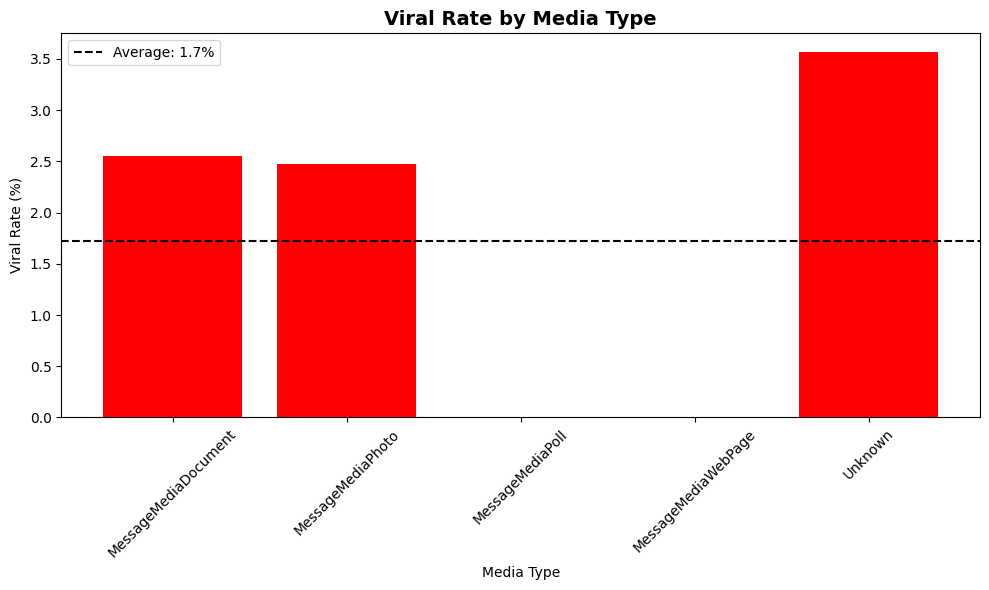

In [73]:
# Viral rate by media type - Fixed & Clean

import matplotlib.pyplot as plt

viral_by_media = posts.groupby('media_type')['is_viral'].mean() * 100
avg_rate = float(viral_by_media.mean())

colors = ['red' if float(v) > avg_rate else 'steelblue' for v in viral_by_media.values]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(viral_by_media.index, viral_by_media.values, color=colors)
ax.axhline(y=avg_rate, color='black', linestyle='--', 
           label=f'Average: {avg_rate:.1f}%')

ax.set_title('Viral Rate by Media Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Media Type')
ax.set_ylabel('Viral Rate (%)')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------------------------
<h5 style= "color:purple"> Call-to-Action (CTA) Engagement Analysis</h5>

Binary indicators are created to detect call-to-action phrases and reward keywords in posts.
Posts with and without these phrases are compared using mean and median comment counts.
A Mann–Whitney U test statistically checks if the difference is significant.
This verifies whether CTA wording, rather than questions, drives higher engagement.
The result provides evidence that specific linguistic patterns influence user interaction.

In [74]:
# Let's examine what post characteristics actually exist
print("📊 ACTUAL POST CHARACTERISTICS:")
print(f"Posts with exclamation marks: {posts['cleaned_text'].str.contains('!').sum()}")
print(f"Posts with emojis (original text): {posts['text'].str.contains('🎁|👍|🎉|⭐').sum()}")
print(f"Posts with 'እንመልስ' (let's answer): {posts['cleaned_text'].str.contains('እንመልስ').sum()}")
print(f"Posts with 'ሽልማት' (prize/reward): {posts['cleaned_text'].str.contains('ሽልማት').sum()}")

# Create new engagement indicators
posts['has_exclamation'] = posts['cleaned_text'].str.contains('!').astype(int)
posts['has_reward_keyword'] = posts['cleaned_text'].str.contains('ሽልማት|ዕጣ|እንሸለም').astype(int)
posts['has_call_to_action'] = posts['cleaned_text'].str.contains('እንመልስ|ንጠቅሱ|ንጻፍ').astype(int)

# Test these instead of questions
cta_engagement = posts.groupby('has_call_to_action')['num_comments'].agg(['mean', 'median', 'count'])
print("\nEngagement: Call-to-Action vs No CTA:")
print(cta_engagement)

# Statistical test
cta_posts = posts[posts['has_call_to_action'] == 1]['num_comments']
no_cta_posts = posts[posts['has_call_to_action'] == 0]['num_comments']
if len(cta_posts) > 0 and len(no_cta_posts) > 0:
    from scipy.stats import mannwhitneyu
    stat, p_val = mannwhitneyu(cta_posts, no_cta_posts)
    print(f"Mann-Whitney U test p-value: {p_val:.4f}")
    print(f"CTAs significantly increase engagement: {'Yes' if p_val < 0.05 else 'No'}")

📊 ACTUAL POST CHARACTERISTICS:
Posts with exclamation marks: 0
Posts with emojis (original text): 389
Posts with 'እንመልስ' (let's answer): 109
Posts with 'ሽልማት' (prize/reward): 122

Engagement: Call-to-Action vs No CTA:
                           mean  median  count
has_call_to_action                            
0                     86.811208    38.0   1838
1                   1152.881818   773.0    110
Mann-Whitney U test p-value: 0.0000
CTAs significantly increase engagement: Yes


<h2 style="color:green">Language Detection Analysis</h2>

In [ ]:
# -----------------------------
# Robust script-based detector
# -----------------------------
AMHARIC_RE = re.compile(r'[\u1200-\u137F]')
ENGLISH_RE = re.compile(r'[a-zA-Z]')

def detect_language_type(text: str) -> str:
    text = str(text)

    # Remove emojis, numbers, punctuation for cleaner detection
    cleaned = re.sub(r'[^a-zA-Z\u1200-\u137F]', '', text)

    if len(cleaned) == 0:
        return "Empty/Emoji/Other"

    has_amharic = bool(AMHARIC_RE.search(cleaned))
    has_english = bool(ENGLISH_RE.search(cleaned))

    if has_amharic and has_english:
        return "Mixed (Amharic + English)"
    elif has_amharic:
        return "Amharic"
    elif has_english:
        return "English"
    else:
        return "Other Script"


# -----------------------------
# Apply to your dataframe
# -----------------------------
comments['language_type'] = comments['cleaned_text'].apply(detect_language_type)

# -----------------------------
# Distribution
# -----------------------------
print("\nLanguage distribution:")
print(comments['language_type'].value_counts())

# -----------------------------
# Show examples from each class
# -----------------------------
for lang in comments['language_type'].unique():
    print(f"\n================ Examples: {lang} ===================")
    display(
        comments[comments['language_type'] == lang][['cleaned_text']]
        .head(5)
    )

----------------------------------------------------------------------------------------------------------
<h3 style="color:green">Network Analysis</h3>

A bipartite network was constructed between users and posts based on comments.  
A co-commenting network was then built to identify users who frequently comment on the same posts.  
Network statistics and degree centrality were calculated to measure user influence and interaction patterns.  
This analysis reveals key active users and community structure in the Telegram discussion.

In [75]:
# ============================================
# 6.2 NETWORK ANALYSIS - FIXED
# ============================================

import networkx as nx
import pandas as pd

# Fix: ensure sender_id is numeric and clean
comments['sender_id'] = pd.to_numeric(comments['sender_id'], errors='coerce')

# Create user-post bipartite network
G = nx.Graph()

# Add post nodes
for _, row in posts.iterrows():
    G.add_node(f"post_{row['msg_id']}", type='post', views=row.get('views', 0))

# Add user nodes and edges (sample for efficiency)
comment_sample_network = comments.sample(n=min(100000, len(comments)), random_state=42)

for _, row in comment_sample_network.iterrows():
    user_id = row['sender_id']
    post_id = row['post_id']
    if pd.notna(user_id):
        user_id = int(user_id)
        G.add_node(f"user_{user_id}", type='user')
        G.add_edge(f"user_{user_id}", f"post_{post_id}")

# Network statistics
print("=== NETWORK STATISTICS ===")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# User-user co-commenting network
user_post_dict = {}
for _, row in comment_sample_network.iterrows():
    user_id = row['sender_id']
    post_id = row['post_id']
    if pd.notna(user_id):
        user_id = int(user_id)
        if post_id not in user_post_dict:
            user_post_dict[post_id] = set()
        user_post_dict[post_id].add(user_id)

# Build co-commenting network
co_comment_G = nx.Graph()
for post_id, users in user_post_dict.items():
    users_list = list(users)
    for i in range(len(users_list)):
        for j in range(i + 1, len(users_list)):
            u1, u2 = users_list[i], users_list[j]
            if co_comment_G.has_edge(u1, u2):
                co_comment_G[u1][u2]['weight'] += 1
            else:
                co_comment_G.add_edge(u1, u2, weight=1)

print(f"\nCo-commenting network nodes: {co_comment_G.number_of_nodes()}")
print(f"Co-commenting network edges: {co_comment_G.number_of_edges()}")

# Top users by degree centrality
degree_centrality = nx.degree_centrality(co_comment_G)
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\n=== TOP 10 USERS BY DEGREE CENTRALITY ===")
for user, centrality in top_degree:
    print(f"User {user}: {centrality:.4f}")

=== NETWORK STATISTICS ===
Number of nodes: 17219
Number of edges: 30504

Co-commenting network nodes: 15249
Co-commenting network edges: 608970

=== TOP 10 USERS BY DEGREE CENTRALITY ===
User 7968479981: 0.4587
User 5726191544: 0.2354
User 5695848541: 0.2276
User 6424639531: 0.1857
User 609992025: 0.1827
User 6490368349: 0.1779
User 7357165397: 0.1692
User 5827231818: 0.1683
User 7371839133: 0.1551
User 7249856496: 0.1544
